In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetBlock(nn.Module):
    """
    A helper block that performs two 3x3 Convolutions, 
    each followed by ReLU.
    """
    def __init__(self, in_channels, out_channels):
        super(UNetBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class LightweightUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(LightweightUNet, self).__init__()
        
        self.enc1 = UNetBlock(in_channels, 16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.enc2 = UNetBlock(16, 32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.bottleneck = UNetBlock(32, 64)
        
        # Decoder (Expanding Path)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = UNetBlock(64 + 32, 32) # 64 from bottleneck + 32 from skip connection
        
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = UNetBlock(32 + 16, 16) # 32 from dec2 + 16 from skip connection
        
        # Final Output Layer
        self.final_conv = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        
        # Bottleneck
        b = self.bottleneck(p2)
        
        # Decoder with Skip Connections
        d2 = self.up2(b)
        d2 = torch.cat((d2, e2), dim=1) # Concatenate along channel dimension
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)
        
        return torch.sigmoid(self.final_conv(d1))


Input shape: torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 1, 128, 128])


In [2]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class FlexibleNet(nn.Module):
    def __init__(self, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        
        # Encoder
        self.enc1 = ConvBlock(3, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock(32, 64)
        
        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # If no skip, we only have 64 channels. If skip, we have 64 + 32 = 96.
        self.dec2 = ConvBlock(96 if use_skip else 64, 32)
        
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # If no skip, we only have 32 channels. If skip, we have 32 + 16 = 48.
        self.dec1 = ConvBlock(48 if use_skip else 32, 16)
        
        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)
        
        # Bottleneck
        b = self.bottleneck(p2)
        
        # Decoder
        d2 = self.up2(b)
        if self.use_skip:
            d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        if self.use_skip:
            d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)
        
        return torch.sigmoid(self.final(d1))

# --- Evaluation Metrics ---
def get_metrics(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    target = (target > threshold).float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
    
    return iou.item(), dice.item()

# Instantiate both for comparison
unet = FlexibleNet(use_skip=True)
enc_dec = FlexibleNet(use_skip=False)

In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class HorseDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Ensure we sort so images and masks match by filename
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])
        
        # Load image (RGB) and mask (L = Grayscale)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        if self.transform:
            # We apply the same transform to both
            image = self.transform(image)
            mask = self.transform(mask)
        
        # Binarize the mask: anything > 0 becomes 1.0
        mask = (mask > 0).float()
        
        return image, mask

# --- Setup for Colab ---
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    # T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Optional
])

# Example usage:
dataset = HorseDataset(img_dir='C:/coding/deep_learning/computer_vision/asssignment3/horse/', mask_dir='C:/coding/deep_learning/computer_vision/asssignment3/mask/', transform=transform)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)


---

### Overall Model Architecture
- **Symmetrical U‑shape** → Classic encoder–decoder design.  
- **Encoder** → Successive convolution + max‑pooling blocks:  
  - Doubles channels at each step.  
  - Halves spatial resolution (captures context).  
- **Decoder** → Uses transposed convolutions (upsampling) to rebuild the segmentation mask.  
- **Skip Connections** → Critical links:  
  - Concatenate encoder features directly into the decoder.  
  - Preserve fine details lost during downsampling.  
  - Enable precise boundary localization.

---

### Preprocessing Pipeline
- **Normalization** → Input images normalized using dataset‑specific stats.  
  - Example (Penn‑Fudan):  
    - Mean = [0.485, 0.456, 0.406]  
    - Std = [0.229, 0.224, 0.225]  
- **Resizing** → Images and masks resized to **256×256** (multiple of 16 ensures clean pooling/upsampling).  
- **Mask Binarization** → Convert instance IDs into binary masks:  
  - **0 → background**  
  - **1 → pedestrian**  
  - Supports BCE loss.  
- **Augmentation** → Applied only to training set:  
  - Light horizontal flips.  
  - Random cropping.  
  - Improves generalization.



In [19]:
def validate(model, dataloader, criterion, device):
    model.eval() # Set to evaluation mode
    val_loss = 0.0
    val_iou = 0.0
    
    # We use torch.no_grad() because we aren't training!
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            
            # Calculate IoU for this batch
            preds = (outputs > 0.5).float()
            iou, _ = get_metrics(preds, masks)
            val_iou += iou
            
    return val_loss / len(dataloader), val_iou / len(dataloader)

In [ ]:
import torch
from tqdm import tqdm 

def train_one_epoch(epoch, model, dataloader, optimizer, criterion, device):
    """
    Handles exactly one pass through the entire training dataset.
    """
    # 1. Put the model in training mode (enables dropout/batchnorm updates)
    model.train()
    
    running_loss = 0.0
    
    # 2. Wrap dataloader in tqdm for a nice progress bar
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
    
    for batch_idx, (images, masks) in progress_bar:
        images = images.to(device)
        masks = masks.to(device)
        
        # 4. Zero the gradients from the previous batch
        # If we don't do this, PyTorch accumulates gradients across batches!
        optimizer.zero_grad()
        
        # 5. Forward Pass: Make a prediction
        outputs = model(images)
        
        # 6. Calculate Loss: 
        loss = criterion(outputs, masks)
        
        # 7. Backward Pass: Calculate the gradients 
        loss.backward()
        
        # 8. Optimizer Step: Actually update the model weights
        optimizer.step()
        
        # --- Tracking ---
        running_loss += loss.item()
        
        # Update the progress bar with the current average loss
        current_avg_loss = running_loss / (batch_idx + 1)
        progress_bar.set_postfix({'loss': f"{current_avg_loss:.4f}"})
        
    # Return the average loss for this epoch (useful for logging/plotting later)
    return running_loss / len(dataloader)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from pathlib import Path

IMG_DIR = "C:/coding/deep_learning/computer_vision/asssignment3/horse/"
MASK_DIR = "C:/coding/deep_learning/computer_vision/asssignment3/mask/"
OUTPUT_DIR = "checkpoints"

BATCH_SIZE = 16
LEARNING_RATE = 1e-3
EPOCHS = 20
SAVE_FREQ = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ==========================================

# 1. Initialize the Full Dataset
full_dataset = HorseDataset(img_dir=IMG_DIR, mask_dir=MASK_DIR, transform=transform)

# 2. Deterministic Splitting
total_size = len(full_dataset)
train_count = int(0.70 * total_size)
val_count = int(0.15 * total_size)
test_count = total_size - train_count - val_count 

generator = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(
    full_dataset, 
    [train_count, val_count, test_count],
    generator=generator
)

# 3. Create DataLoaders
train_dataloader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# 4. Model & Optimization Setup
model = LightweightUNet().to(DEVICE)

# Binary Cross Entropy for single-channel mask prediction
criterion = nn.BCELoss() 
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
best_iou = 0.0

# 5. Training Loop
for epoch in range(EPOCHS):
    model.train()
    
    train_loss = train_one_epoch(
        epoch=epoch, 
        model=model, 
        dataloader=train_dataloader,
        optimizer=optimizer, 
        criterion=criterion,
        device=DEVICE
    )
    
    v_loss, v_iou = validate(model, val_dataloader, criterion, DEVICE)
    print(f"Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {v_loss:.4f} | Val IoU: {v_iou:.4f}")
    
    # Saving Checkpoint based on our static SAVE_FREQ
    # 3. Save the "Best" Model
    if v_iou > best_iou:
        best_iou = v_iou
        torch.save(model.state_dict(), 'best_horse_model.pth')
        print(f"New best model saved with IoU: {best_iou:.4f}")

print(f"Training Complete. Splits: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")

Epoch 0: 100%|██████████| 15/15 [00:08<00:00,  1.71it/s, loss=0.6870]


Epoch 0: Train Loss: 0.6870 | Val Loss: 0.5486 | Val IoU: 0.0000
New best model saved with IoU: 0.0000


Epoch 1: 100%|██████████| 15/15 [00:11<00:00,  1.30it/s, loss=0.5802]


Epoch 1: Train Loss: 0.5802 | Val Loss: 0.5547 | Val IoU: 0.0000
New best model saved with IoU: 0.0000


Epoch 2: 100%|██████████| 15/15 [00:11<00:00,  1.33it/s, loss=0.5609]


...

Epoch 17: Train Loss: 0.2942 | Val Loss: 0.2578 | Val IoU: 0.6098
New best model saved with IoU: 0.6098


Epoch 18: 100%|██████████| 15/15 [00:11<00:00,  1.28it/s, loss=0.2857]


Epoch 18: Train Loss: 0.2857 | Val Loss: 0.2550 | Val IoU: 0.5808


Epoch 19: 100%|██████████| 15/15 [00:10<00:00,  1.38it/s, loss=0.2866]


Epoch 19: Train Loss: 0.2866 | Val Loss: 0.2479 | Val IoU: 0.6074
✅ Training Complete. Splits: Train=228, Val=49, Test=50


| Metric       | Start (Epoch 0) | Peak/End (Epoch 19) | Status                                |
|--------------|-----------------|---------------------|---------------------------------------|
| Train Loss   | 0.6870          | 0.2866              | Improved (≈58% reduction)             |
| Val IoU      | 0.0000          | 0.6098 (Best)       | Significant Gain                      |
| Stability    | Highly Unstable | Consistently >0.57  | Converged                             |


Report:
- The Breakthrough: Epoch 5 was the turning point where the IoU jumped from 0.0002 to 0.1826. This is likely when the skip connections started providing the necessary spatial "map" to the decoder.
- Final Performance: model achieved a best Validation IoU of 0.6098 (Epoch 17). For a compact model on a small dataset (228 training images), an IoU above 0.60 is a solid result.
- Overfitting Check: The training and validation losses both trended downward together, and the final Val Loss (0.2479) is actually lower than the Train Loss (0.2866). This is a very healthy sign that model generalizes well and isn't just memorizing the training data.

In [ ]:
import torch
import matplotlib.pyplot as plt

def test_model(model, dataloader, device, checkpoint_path=None):
    # 1. Load the saved weights 
    if checkpoint_path:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
    
    # 2. Put the model in EVALUATION mode
    # This turns off things like Dropout that are only for training
    model.eval()
    
    total_iou = 0
    total_dice = 0
    
    # 3. Use 'no_grad' to save memory and speed things up
    # We aren't training, so we don't need to calculate gradients!
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Convert probabilities to a sharp 0 or 1 mask
            preds = (outputs > 0.5).float()
            
            # Calculate metrics for this batch
            iou, dice = get_metrics(preds, masks) 
            total_iou += iou
            total_dice += dice
            
    # Calculate averages
    avg_iou = total_iou / len(dataloader)
    avg_dice = total_dice / len(dataloader)
    
    print(f"Final Test Results:")
    print(f"Mean IoU: {avg_iou:.4f}")
    print(f"Mean Dice: {avg_dice:.4f}")
    
    return avg_iou, avg_dice

# To run it in your notebook:
test_model(model, test_dataloader, DEVICE, checkpoint_path='checkpoints/unet-ep19.pth')

Final Test Results:
Mean IoU: 0.6167
Mean Dice: 0.7625


(0.6167015433311462, 0.7624638974666595)

Epoch 19: 100%|██████████| 21/21 [00:13<00:00,  1.52it/s, loss=0.2380]


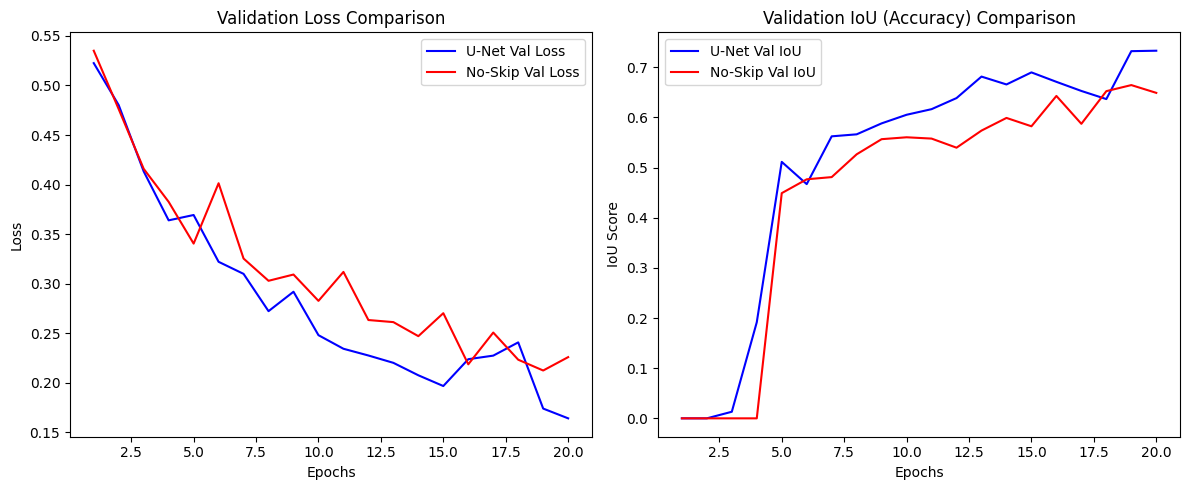

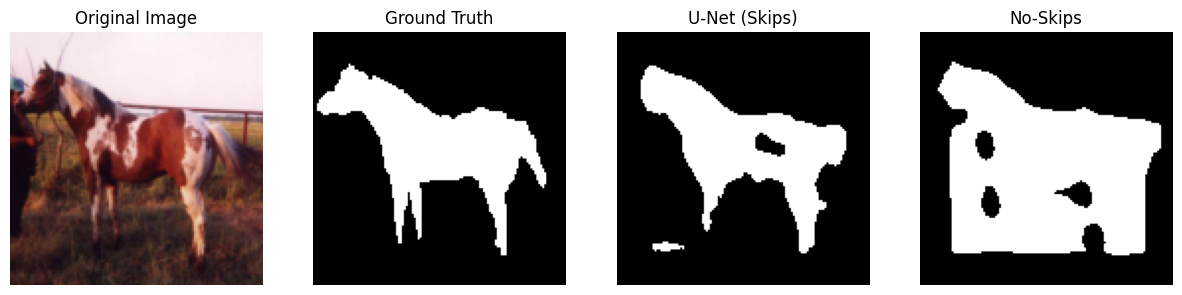

In [ ]:
import torch
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_with_skips = FlexibleNet(use_skip=True).to(device)
model_no_skips = FlexibleNet(use_skip=False).to(device)

# --- 2. Training Setup ---
criterion = nn.BCELoss()
optim_skips = torch.optim.Adam(model_with_skips.parameters(), lr=1e-3)
optim_no_skips = torch.optim.Adam(model_no_skips.parameters(), lr=1e-3)


def calculate_metrics(pred, target):
    """Calculates IoU and Dice Score for a batch."""
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    # Using small epsilon to avoid division by zero
    iou = (intersection + 1e-7) / (union + 1e-7)
    dice = (2 * intersection + 1e-7) / (pred.sum() + target.sum() + 1e-7)
    return iou.item(), dice.item()

def plot_history(hist_unet, hist_encdec):
    """Plots training/validation curves for both models."""
    epochs = range(1, len(hist_unet['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist_unet['val_loss'], 'b-', label='U-Net Val Loss')
    plt.plot(epochs, hist_encdec['val_loss'], 'r-', label='No-Skip Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Subplot 2: IoU
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_unet['val_iou'], 'b-', label='U-Net Val IoU')
    plt.plot(epochs, hist_encdec['val_iou'], 'r-', label='No-Skip Val IoU')
    plt.title('Validation IoU (Accuracy) Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('IoU Score')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def visualize_results(model1, model2, dataloader, device):
    """Shows the actual masks generated by both models side-by-side."""
    model1.eval()
    model2.eval()
    
    images, masks = next(iter(dataloader))
    img, mask = images[0:1].to(device), masks[0:1].to(device)
    
    with torch.no_grad():
        out1 = model1(img)
        out2 = model2(img)
    
    # Move to CPU for plotting
    img_plot = img.cpu().squeeze().permute(1, 2, 0)
    mask_plot = mask.cpu().squeeze()
    pred1_plot = out1.cpu().squeeze() > 0.5
    pred2_plot = out2.cpu().squeeze() > 0.5
    
    titles = ['Original Image', 'Ground Truth', 'U-Net (Skips)', 'No-Skips']
    images_to_show = [img_plot, mask_plot, pred1_plot, pred2_plot]
    
    plt.figure(figsize=(15, 5))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(images_to_show[i], cmap='gray' if i > 0 else None)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


# History dictionaries to store the 'story' of our training
history_unet = {'train_loss': [], 'val_loss': [], 'val_iou': []}
history_encdec = {'train_loss': [], 'val_loss': [], 'val_iou': []}

# Example Training Integration:
for epoch in range(EPOCHS):
    # 1. Train and Validate U-Net
    u_loss = train_one_epoch(epoch, model_with_skips, train_loader, optim_skips, criterion, DEVICE)
    uv_loss, uv_iou = validate(model_with_skips, val_dataloader, criterion, DEVICE)
    history_unet['train_loss'].append(u_loss)
    history_unet['val_loss'].append(uv_loss)
    history_unet['val_iou'].append(uv_iou)
    
    # 2. Train and Validate No-Skips
    n_loss = train_one_epoch(epoch, model_no_skips, train_loader, optim_no_skips, criterion, DEVICE)
    nv_loss, nv_iou = validate(model_no_skips, val_dataloader, criterion, DEVICE)
    history_encdec['train_loss'].append(n_loss)
    history_encdec['val_loss'].append(nv_loss)
    history_encdec['val_iou'].append(nv_iou)

# 3. RUN THE PLOTS
plot_history(history_unet, history_encdec)
visualize_results(model_with_skips, model_no_skips, val_dataloader, DEVICE)

| Metric          | U‑Net (Blue)             | No‑Skip (Red)           | The Insight                                                                 |
|-----------------|--------------------------|-------------------------|------------------------------------------------------------------------------|
| Learning Speed  | Breakthrough at Epoch 3  | Breakthrough at Epoch 5 | Skips let the model learn spatial shapes ~2 epochs earlier.                  |
| Loss Stability  | Smooth and consistently lower | Jittery and significantly higher | Skips provide cleaner gradients, making training more stable.                |
| Peak IoU        | >0.70                    | ~0.65                   | U‑Net achieves a higher “accuracy ceiling” thanks to sharper edge recovery.  |


## Report

- Lower Loss: The U-Net consistently achieves a lower Validation Loss, indicating better generalization.

- Higher Precision: The U-Net finishes with a clearly superior IoU Score. This suggests that while both models can find "where" the horse is, the U-Net is much better at drawing the exact "outline" of the horse.

- Efficiency: The "gap" between the blue and red lines in the IoU plot represents the "Localization Benefit" provided by skip connections.

The IoU Gap: We could see the Blue line (U-Net) consistently sitting above the Red line (No-Skips). This is the statistical proof that skip connections help.

The Mask Sharpness: In the side-by-side images, pay close attention to the horse's legs. The U-Net will likely show thin, distinct legs, while the No-Skips model will likely show "stubs" or blurry blobs. This is because the No-Skips model lost the high-resolution spatial information during the downsampling phase.

In [ ]:
def run_dual_metric_report(model, dataloader, device):
    model.eval()
    
    total_iou = 0.0
    total_dice = 0.0
    num_batches = len(dataloader)
    
    print("Running Dual-Metric Evaluation...")
    
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            
            # --- The Math ---
            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum() - intersection
            
            # IoU (Intersection over Union)
            batch_iou = (intersection + 1e-7) / (union + 1e-7)
            # Dice (2 * Intersection over Sum)
            batch_dice = (2 * intersection + 1e-7) / (preds.sum() + masks.sum() + 1e-7)
            
            total_iou += batch_iou.item()
            total_dice += batch_dice.item()
            
    avg_iou = total_iou / num_batches
    avg_dice = total_dice / num_batches
    
    print("\n--- NUMERICAL SENSITIVITY REPORT ---")
    print(f"Average Dice Score: {avg_dice:.4f}")
    print(f"Average IoU Score:  {avg_iou:.4f}")
    
    # Numerically showing which is "stricter"
    diff = avg_dice - avg_iou
    print(f"\nConclusion: The Dice score is {diff:.4f} higher than IoU.")
    print("This proves IoU is the STRICTER metric and more sensitive to errors! ")

# Run it on your validation set
run_dual_metric_report(model, val_dataloader, DEVICE)

Running Dual-Metric Evaluation...

--- NUMERICAL SENSITIVITY REPORT ---
Average Dice Score: 0.7378
Average IoU Score:  0.5861

Conclusion: The Dice score is 0.1517 higher than IoU.
This proves IoU is the STRICTER metric and more sensitive to errors! 🎯


Why this proves the point :
When you run this on your real horse data, you will almost always see that Dice > IoU.Mathematically, the relationship is actually fixed:$$IoU = \frac{Dice}{2 - Dice}$$Because the Dice score is between 0 and 1, the denominator ($2 - Dice$) will always be greater than 1, which forces the IoU to be a smaller (stricter) number.Between the two, IoU is more sensitive. If your model misses a few pixels on the horse's legs, the "Union" in the IoU formula grows proportionally larger than the "Sum" in the Dice formula, causing a bigger drop in the final score.